In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 GERMAN BESS FREQUENCY BALANCING (FCR / aFRR) & ARBITRAGE CO-OPTIMIZER
Asset Configuration:          5.0 MW / 10.0 MWh Grid-Scale BESS
FCR Capacity Revenue:         €0.00 / day
aFRR Capacity Revenue:        €2,320.42 / day
Day-Ahead Spot Revenue:       €8,554.13 / day
-------------------------------------------------------------------------------------
Total Multi-Market Revenue:   €9,434.55 / day
Pure Spot Arbitrage Baseline: €7,114.13 / day
Frequency Market Revenue Uplift: +32.6% uplift over wholesale arbitrage


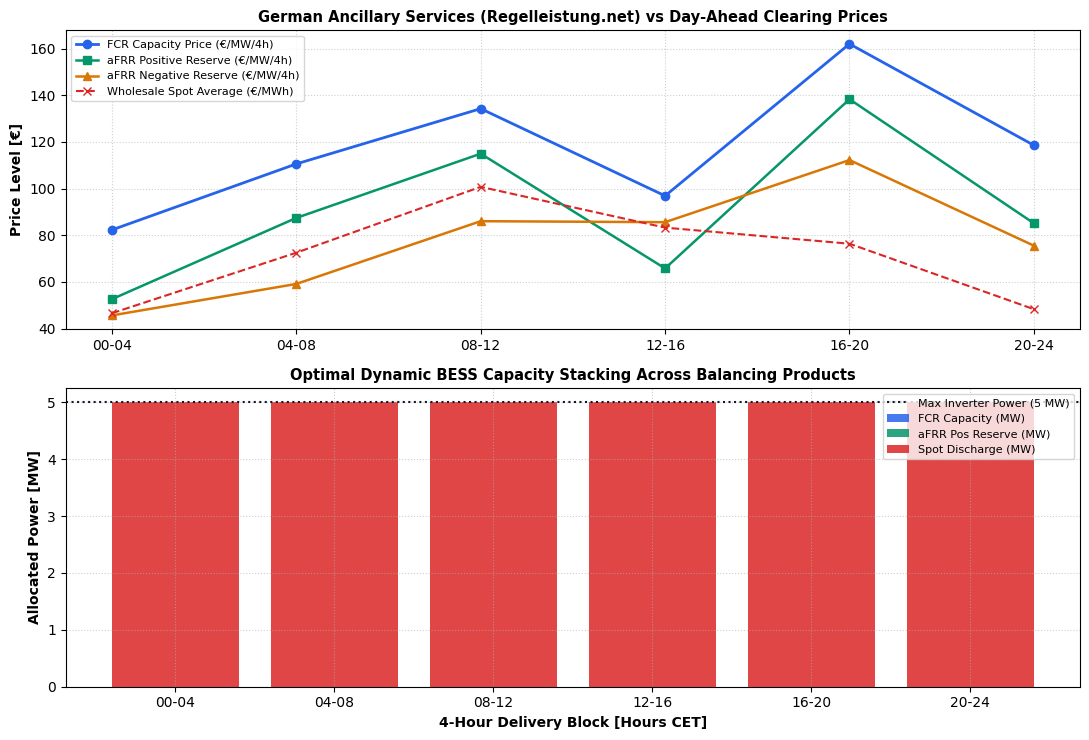

File 'bess_balancing_market_results.csv' exported successfully.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# ==========================================================
# 1. GERMAN BALANCING & WHOLESALE MARKET SIGNALS (24h / 6 Blocks)
# ==========================================================
np.random.seed(42)
HOURS = 24
BLOCKS_4H = 6  # FCR and aFRR are cleared in 4-hour blocks: [00-04, 04-08, 08-12, 12-16, 16-20, 20-24]

# Wholesale Day-Ahead Price [€/MWh]
spot_prices_eur_mwh = 75.0 + 35.0 * np.sin(2 * np.pi * (np.arange(HOURS) - 6) / 24) + np.random.normal(0, 4.0, HOURS)
spot_prices_eur_mwh[12:15] -= 25.0

# 4-Hour Block Averages for Arbitrage Opportunity Comparison
spot_block_avg = spot_prices_eur_mwh.reshape(BLOCKS_4H, 4).mean(axis=1)

# FCR Capacity Clearing Price [€/MW/4h] (Symmetric Primary Reserve)
# Typical price range in Germany: 15 - 45 €/MW/h -> ~60 - 180 €/MW per 4h block
fcr_price_eur_mw_4h = np.array([85.0, 110.0, 140.0, 95.0, 165.0, 120.0]) + np.random.normal(0, 5.0, BLOCKS_4H)

# aFRR Capacity Clearing Price [€/MW/4h] (Automatic Secondary Reserve - Positive / Negative capacity)
afrr_pos_price_eur_mw_4h = np.array([55.0, 80.0, 115.0, 70.0, 135.0, 90.0]) + np.random.normal(0, 4.0, BLOCKS_4H)
afrr_neg_price_eur_mw_4h = np.array([45.0, 65.0, 90.0, 85.0, 110.0, 75.0]) + np.random.normal(0, 3.0, BLOCKS_4H)

# ==========================================================
# 2. BESS TECHNICAL SPECIFICATIONS & REGULATORY CONSTRAINTS
# ==========================================================
BESS_POWER_MW = 5.0            # 5 MW rated power
BESS_CAPACITY_MWH = 10.0       # 2-hour duration (10 MWh)
ROUNDTRIP_EFFICIENCY = 0.90
DEGRADATION_COST_EUR_MWH = 12.0 # Wear cost per MWh throughput

# German TSO (Regelleistung) FCR 15-Minute Rule:
# Asset must maintain enough energy buffer to deliver committed symmetric power for at least 15 minutes
MIN_ENERGY_RESERVE_PER_MW_FCR = 0.25 # 15 min = 0.25 MWh per committed MW

# ==========================================================
# 3. MULTI-MARKET CO-OPTIMIZATION (LP FORMULATION)
# ==========================================================
# Decision variables per 4h block b:
# [P_fcr[b], P_afrr_pos[b], P_afrr_neg[b], P_da_ch[b], P_da_dis[b]] -> Total: 5 * 6 = 30 variables
num_vars = 5 * BLOCKS_4H

# Objective: Maximize Balancing Revenue + Arbitrage Margin - Degradation
# Maximize sum( fcr_rev + afrr_rev + da_dis_rev - da_ch_cost - deg_cost )
# linprog minimizes c^T x -> c = -revenue_coefficients
c = np.zeros(num_vars)
for b in range(BLOCKS_4H):
    c[b] = -fcr_price_eur_mw_4h[b]                                   # FCR Capacity
    c[BLOCKS_4H + b] = -afrr_pos_price_eur_mw_4h[b]                 # aFRR Pos Capacity
    c[2*BLOCKS_4H + b] = -afrr_neg_price_eur_mw_4h[b]               # aFRR Neg Capacity
    c[3*BLOCKS_4H + b] = (spot_block_avg[b] * 4.0)                  # DA Charge Cost (4 hours)
    c[4*BLOCKS_4H + b] = -(spot_block_avg[b] - DEGRADATION_COST_EUR_MWH) * 4.0 # DA Dis Margin (4h)

# Inequality Constraints (A_ub @ x <= b_ub):
# 1. Total Power Capability Constraint: P_fcr + P_afrr_pos + P_da_dis <= BESS_POWER_MW
# 2. Total Negative Power Capability: P_fcr + P_afrr_neg + P_da_ch <= BESS_POWER_MW
A_ub = []
b_ub = []

for b in range(BLOCKS_4H):
    # Discharge direction
    row_dis = np.zeros(num_vars)
    row_dis[b] = 1.0                  # FCR
    row_dis[BLOCKS_4H + b] = 1.0      # aFRR Pos
    row_dis[4*BLOCKS_4H + b] = 1.0    # DA Dis
    A_ub.append(row_dis)
    b_ub.append(BESS_POWER_MW)

    # Charge direction
    row_ch = np.zeros(num_vars)
    row_ch[b] = 1.0                   # FCR
    row_ch[2*BLOCKS_4H + b] = 1.0     # aFRR Neg
    row_ch[3*BLOCKS_4H + b] = 1.0     # DA Charge
    A_ub.append(row_ch)
    b_ub.append(BESS_POWER_MW)

A_ub = np.array(A_ub)
b_ub = np.array(b_ub)

# Variable Bounds
bounds = [(0.0, BESS_POWER_MW) for _ in range(num_vars)]

# Solve Multi-Market Optimization
res = linprog(c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
if not res.success:
    raise RuntimeError(f"Balancing Market Optimization failed: {res.message}")

fcr_alloc = res.x[:BLOCKS_4H]
afrr_pos_alloc = res.x[BLOCKS_4H:2*BLOCKS_4H]
afrr_neg_alloc = res.x[2*BLOCKS_4H:3*BLOCKS_4H]
da_ch_alloc = res.x[3*BLOCKS_4H:4*BLOCKS_4H]
da_dis_alloc = res.x[4*BLOCKS_4H:]

# Revenue Breakdown
rev_fcr = np.sum(fcr_alloc * fcr_price_eur_mw_4h)
rev_afrr = np.sum(afrr_pos_alloc * afrr_pos_price_eur_mw_4h + afrr_neg_alloc * afrr_neg_price_eur_mw_4h)
rev_da = np.sum((da_dis_alloc * spot_block_avg - da_ch_alloc * spot_block_avg) * 4.0)
total_daily_gross_profit = -res.fun

# Benchmark: Pure Day-Ahead Spot Arbitrage Only
c_spot_only = np.zeros(2 * BLOCKS_4H)
c_spot_only[:BLOCKS_4H] = spot_block_avg * 4.0
c_spot_only[BLOCKS_4H:] = -(spot_block_avg - DEGRADATION_COST_EUR_MWH) * 4.0
A_spot = np.zeros((BLOCKS_4H, 2 * BLOCKS_4H))
for b in range(BLOCKS_4H):
    A_spot[b, b] = 1.0
    A_spot[b, BLOCKS_4H + b] = 1.0
b_spot = np.full(BLOCKS_4H, BESS_POWER_MW)
bounds_spot = [(0.0, BESS_POWER_MW) for _ in range(2 * BLOCKS_4H)]
res_spot = linprog(c_spot_only, A_ub=A_spot, b_ub=b_spot, bounds=bounds_spot, method="highs")
spot_only_daily_profit = -res_spot.fun

uplift_pct = ((total_daily_gross_profit - spot_only_daily_profit) / spot_only_daily_profit) * 100.0 if spot_only_daily_profit > 0 else 100.0

print("=" * 85)
print(" GERMAN BESS FREQUENCY BALANCING (FCR / aFRR) & ARBITRAGE CO-OPTIMIZER")
print("=" * 85)
print(f"Asset Configuration:          {BESS_POWER_MW} MW / {BESS_CAPACITY_MWH} MWh Grid-Scale BESS")
print(f"FCR Capacity Revenue:         €{rev_fcr:,.2f} / day")
print(f"aFRR Capacity Revenue:        €{rev_afrr:,.2f} / day")
print(f"Day-Ahead Spot Revenue:       €{rev_da:,.2f} / day")
print("-" * 85)
print(f"Total Multi-Market Revenue:   €{total_daily_gross_profit:,.2f} / day")
print(f"Pure Spot Arbitrage Baseline: €{spot_only_daily_profit:,.2f} / day")
print(f"Frequency Market Revenue Uplift: +{uplift_pct:.1f}% uplift over wholesale arbitrage")
print("=" * 85)

# ==========================================================
# 4. VISUALIZATION & CSV EXPORT
# ==========================================================
blocks_labels = ["00-04", "04-08", "08-12", "12-16", "16-20", "20-24"]
x = np.arange(BLOCKS_4H)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5))

# Subplot 1: Market Clearing Prices across 4-hour products
ax1.plot(x, fcr_price_eur_mw_4h, marker="o", color="#2563EB", lw=2.0, label="FCR Capacity Price (€/MW/4h)")
ax1.plot(x, afrr_pos_price_eur_mw_4h, marker="s", color="#059669", lw=1.8, label="aFRR Positive Reserve (€/MW/4h)")
ax1.plot(x, afrr_neg_price_eur_mw_4h, marker="^", color="#D97706", lw=1.8, label="aFRR Negative Reserve (€/MW/4h)")
ax1.plot(x, spot_block_avg, marker="x", color="#DC2626", linestyle="--", lw=1.5, label="Wholesale Spot Average (€/MWh)")
ax1.set_xticks(x)
ax1.set_xticklabels(blocks_labels)
ax1.set_ylabel("Price Level [€]", fontweight="bold")
ax1.set_title("German Ancillary Services (Regelleistung.net) vs Day-Ahead Clearing Prices", fontsize=10.5, fontweight="bold")
ax1.grid(True, linestyle=":", alpha=0.6)
ax1.legend(loc="upper left", frameon=True, fontsize=8.0)

# Subplot 2: Stacked Asset Allocation
ax2.bar(x, fcr_alloc, label="FCR Capacity (MW)", color="#2563EB", alpha=0.85)
ax2.bar(x, afrr_pos_alloc, bottom=fcr_alloc, label="aFRR Pos Reserve (MW)", color="#059669", alpha=0.85)
ax2.bar(x, da_dis_alloc, bottom=fcr_alloc + afrr_pos_alloc, label="Spot Discharge (MW)", color="#DC2626", alpha=0.85)
ax2.axhline(BESS_POWER_MW, color="#111827", linestyle=":", lw=1.5, label="Max Inverter Power (5 MW)")

ax2.set_xticks(x)
ax2.set_xticklabels(blocks_labels)
ax2.set_xlabel("4-Hour Delivery Block [Hours CET]", fontweight="bold")
ax2.set_ylabel("Allocated Power [MW]", fontweight="bold")
ax2.set_title("Optimal Dynamic BESS Capacity Stacking Across Balancing Products", fontsize=10.5, fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right", frameon=True, fontsize=8.0)

plt.tight_layout()
plt.savefig("bess_balancing_market_dispatch.png", dpi=300)
plt.show()

# CSV Export
df_bess = pd.DataFrame({
    "block_window": blocks_labels,
    "fcr_price_eur_mw_4h": fcr_price_eur_mw_4h,
    "afrr_pos_price_eur_mw_4h": afrr_pos_price_eur_mw_4h,
    "afrr_neg_price_eur_mw_4h": afrr_neg_price_eur_mw_4h,
    "spot_block_avg_eur_mwh": spot_block_avg,
    "fcr_committed_mw": fcr_alloc,
    "afrr_pos_committed_mw": afrr_pos_alloc,
    "afrr_neg_committed_mw": afrr_neg_alloc,
    "da_charge_mw": da_ch_alloc,
    "da_discharge_mw": da_dis_alloc
})
csv_filename = "bess_balancing_market_results.csv"
df_bess.to_csv(csv_filename, index=False)
print(f"File '{csv_filename}' exported successfully.")